<a href="https://colab.research.google.com/github/nancy-shehata/healthy_hrv_model/blob/iteration-2/LSTM_W_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL A — Load all 54 subjects in ms, save per-subject stats
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

rr_root = "/content/drive/MyDrive/ALS Heart Rate Data/NSR Processed/RR Intervals"

def load_rr_file(file_path):
    signal = np.loadtxt(file_path)
    signal = np.asarray(signal, dtype=np.float32)
    signal = signal[~np.isnan(signal)]
    # artifact filter: keep only physiologically valid beats (300-2000ms)
    signal = signal[(signal >= 300) & (signal <= 2000)]
    return signal

# Check if the directory exists before attempting to list its contents
if not os.path.exists(rr_root):
    print(f"Error: The directory '{rr_root}' was not found. Please ensure Google Drive is mounted and the path is correct.")
    rr_signals = {}
    subject_stats = {}
else:
    # Load all 54 subjects — keep in ms
    rr_signals = {}
    for file_name in sorted(os.listdir(rr_root)):
        if file_name.endswith(".txt"):
            full_path = os.path.join(rr_root, file_name)
            rr_signals[file_name] = load_rr_file(full_path)

    print(f"Loaded {len(rr_signals)} subjects")

    # Save per-subject mean and std in ms — needed for denormalization later
    subject_stats = {}
    for name, sig in rr_signals.items():
        subject_stats[name] = {
            "mean": float(np.mean(sig)),
            "std":  float(np.std(sig)) if np.std(sig) > 0 else 1.0
        }

    if rr_signals:
        print("Sample stats (first subject):")
        first = list(subject_stats.values())[0]
        print(f"  mean RR: {first['mean']:.1f} ms,  std: {first['std']:.1f} ms")
    else:
        print("No RR signals loaded to compute sample stats.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 54 subjects
Sample stats (first subject):
  mean RR: 759.2 ms,  std: 169.7 ms


In [ ]:
# ============================================================
# CELL B — Helper functions (sequences, model builder, HRV metrics)
# ============================================================
# HOW TO USE FOR SENSITIVITY ANALYSIS:
#   Change ONE parameter at a time, rerun Cell B + C + D,
#   and compare the results. Keep all others at their baseline.
#
#   Parameter        | Baseline | Updated  | What it controls
#   -----------------|----------|----------|-----------------------------------------
#   SEQ_LENGTH       |  20      |  50      | How many past beats the LSTM sees
#   STEP_SIZE        |  10      |  10      | Sliding window stride
#   GEN_LENGTH       | 1000     | 1000     | Beats to generate per subject
#   LSTM_UNITS_1     |  64      | 128      | Neurons in first LSTM layer
#   LSTM_UNITS_2     |  32      |  64      | Neurons in second LSTM layer
#   DENSE_UNITS      |  16      |  32      | Neurons in hidden Dense layer
#   DROPOUT_RATE     |   0.2    |   0.3    | Dropout fraction after each LSTM
#   NOISE_STD        |   0.25   |   0.15   | Noise injected at each generation step
#   EPOCHS           |  20      |  20      | Max training epochs per fold
#   BATCH_SIZE       | 128      | 256      | Mini-batch size during training
#   INNER_K          |   5      |   5      | Inner folds for hyperparameter tuning
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ── Change ONE of these at a time ────────────────────────────────────────────
SEQ_LENGTH    = 50     # updated: 50  | baseline: 20  | try: 10, 30, 100
STEP_SIZE     = 10     # baseline: 10 | try: 1, 5, 20
GEN_LENGTH    = 1000   # baseline: 1000 | try: 500, 2000

LSTM_UNITS_1  = 128    # updated: 128 | baseline: 64  | try: 16, 32, 256
LSTM_UNITS_2  = 64     # updated: 64  | baseline: 32  | try: 8, 16, 128
DENSE_UNITS   = 32     # updated: 32  | baseline: 16  | try: 8, 64
DROPOUT_RATE  = 0.3    # updated: 0.3 | baseline: 0.2 | try: 0.0, 0.1, 0.5
NOISE_STD     = 0.15   # updated: 0.15| baseline: 0.25| try: 0.0, 0.05, 0.10, 0.25

EPOCHS        = 20     # baseline: 20 | try: 10, 30, 50
BATCH_SIZE    = 256    # updated: 256 | baseline: 128 | try: 32, 64
INNER_K       = 5      # baseline: 5  | try: 3, 10
# ─────────────────────────────────────────────────────────────────────────────

def create_sequences(signal_norm, seq_length=SEQ_LENGTH, step_size=STEP_SIZE):
    X, y = [], []
    if len(signal_norm) <= seq_length:
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
    for i in range(0, len(signal_norm) - seq_length, step_size):
        X.append(signal_norm[i : i + seq_length])
        y.append(signal_norm[i + seq_length])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def build_model(seq_length=SEQ_LENGTH):
    model = Sequential([
        LSTM(LSTM_UNITS_1, input_shape=(seq_length, 1), return_sequences=True),
        Dropout(DROPOUT_RATE),
        LSTM(LSTM_UNITS_2),
        Dropout(DROPOUT_RATE),
        Dense(DENSE_UNITS, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

def compute_hrv_metrics(rr_ms):
    rr      = np.array(rr_ms, dtype=np.float64)
    mean_rr = np.mean(rr)
    sdnn    = np.std(rr, ddof=1)
    diff    = np.diff(rr)
    rmssd   = np.sqrt(np.mean(diff ** 2))
    sd1     = np.std(diff, ddof=1) / np.sqrt(2)
    sd2     = np.sqrt(2 * sdnn**2 - sd1**2)
    return {"mean_rr": mean_rr, "sdnn": sdnn, "rmssd": rmssd, "sd1": sd1, "sd2": sd2}

def generate_sequence(model, seed_beats_norm, gen_length, mean_ms, std_ms, noise_std=NOISE_STD):
    buffer = list(seed_beats_norm[-SEQ_LENGTH:])
    generated_norm = []

    for step in range(gen_length):
        x_in = np.array(buffer[-SEQ_LENGTH:], dtype=np.float32).reshape(1, SEQ_LENGTH, 1)
        next_beat_norm = model.predict(x_in, verbose=0)[0, 0]

        # Adaptive noise — scales with recent buffer variability
        if len(buffer) >= 20:
            recent_std = float(np.std(buffer[-20:]))
            # If recent variability is too low, boost noise to compensate
            effective_noise = max(noise_std, recent_std * 0.8)
        else:
            effective_noise = noise_std

        next_beat_norm += np.random.normal(0, effective_noise)
        generated_norm.append(next_beat_norm)
        buffer.append(next_beat_norm)

    generated_ms = np.array(generated_norm) * std_ms + mean_ms
    return generated_ms

print("Cell B loaded. Current hyperparameters:")
print(f"  SEQ_LENGTH={SEQ_LENGTH}, STEP_SIZE={STEP_SIZE}, GEN_LENGTH={GEN_LENGTH}")
print(f"  LSTM_UNITS_1={LSTM_UNITS_1}, LSTM_UNITS_2={LSTM_UNITS_2}, DENSE_UNITS={DENSE_UNITS}")
print(f"  DROPOUT_RATE={DROPOUT_RATE}, NOISE_STD={NOISE_STD}")
print(f"  EPOCHS={EPOCHS}, BATCH_SIZE={BATCH_SIZE}, INNER_K={INNER_K}")

Cell B loaded. Current hyperparameters:
  SEQ_LENGTH=50, STEP_SIZE=10, GEN_LENGTH=1000
  LSTM_UNITS_1=128, LSTM_UNITS_2=64, DENSE_UNITS=32
  DROPOUT_RATE=0.3, NOISE_STD=0.15
  EPOCHS=20, BATCH_SIZE=256, INNER_K=5


In [ ]:
import os

CHECKPOINT_PATH = "/content/drive/MyDrive/ALS Heart Rate Data/ lstm_loocv_results_v3.csv"

if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print("Checkpoint deleted — will rerun from fold 1")
else:
    print("No checkpoint found")

No checkpoint found


In [ ]:
# ============================================================
# CELL C1 — K-Fold Hyperparameter Tuning
# Run this ONCE to find the best hyperparameters globally,
# then use those in Cell C2 for LOOCV evaluation.
# ============================================================

import itertools
import pandas as pd
from sklearn.model_selection import KFold

HYPERPARAM_GRID = {
    "lstm_units_1": [64, 128],
    "lstm_units_2": [32, 64],
    "dropout_rate": [0.2, 0.3],
}
all_combos = [
    dict(zip(HYPERPARAM_GRID.keys(), vals))
    for vals in itertools.product(*HYPERPARAM_GRID.values())
]
print(f"Total hyperparameter combos: {len(all_combos)}")

def build_model_hp(hp):
    model = Sequential([
        LSTM(hp["lstm_units_1"], input_shape=(SEQ_LENGTH, 1), return_sequences=True),
        Dropout(hp["dropout_rate"]),
        LSTM(hp["lstm_units_2"]),
        Dropout(hp["dropout_rate"]),
        Dense(DENSE_UNITS, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

# Pool all subjects together for K-Fold tuning
X_pool, y_pool = [], []
for name in sorted(rr_signals.keys()):
    stats = subject_stats[name]
    sig_n = (rr_signals[name] - stats["mean"]) / stats["std"]
    X_s, y_s = create_sequences(sig_n)
    if len(X_s) == 0:
        continue
    X_pool.append(X_s)
    y_pool.append(y_s)

X_pool = np.concatenate(X_pool).reshape(-1, SEQ_LENGTH, 1)
y_pool = np.concatenate(y_pool)
print(f"Total windows for tuning: {len(X_pool)}")

# Run K-Fold for each combo
kf = KFold(n_splits=INNER_K, shuffle=True, random_state=42)
best_hp, best_score = None, float("inf")

for hp in all_combos:
    fold_losses = []
    for tr_idx, val_idx in kf.split(X_pool):
        model = build_model_hp(hp)
        es = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
        hist = model.fit(
            X_pool[tr_idx], y_pool[tr_idx],
            validation_data=(X_pool[val_idx], y_pool[val_idx]),
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            callbacks=[es], verbose=0
        )
        fold_losses.append(min(hist.history["val_loss"]))
    mean_loss = float(np.mean(fold_losses))
    print(f"  HP: {hp} → mean val_loss: {mean_loss:.5f}")
    if mean_loss < best_score:
        best_score = mean_loss
        best_hp = hp

print(f"\nBest hyperparameters: {best_hp}")
print(f"Best K-Fold val_loss: {best_score:.5f}")

Total hyperparameter combos: 8
Total windows for tuning: 578525


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  HP: {'lstm_units_1': 64, 'lstm_units_2': 32, 'dropout_rate': 0.2} → mean val_loss: 0.08149
  HP: {'lstm_units_1': 64, 'lstm_units_2': 32, 'dropout_rate': 0.3} → mean val_loss: 0.09248
  HP: {'lstm_units_1': 64, 'lstm_units_2': 64, 'dropout_rate': 0.2} → mean val_loss: 0.07130
  HP: {'lstm_units_1': 64, 'lstm_units_2': 64, 'dropout_rate': 0.3} → mean val_loss: 0.07625
  HP: {'lstm_units_1': 128, 'lstm_units_2': 32, 'dropout_rate': 0.2} → mean val_loss: 0.08102
  HP: {'lstm_units_1': 128, 'lstm_units_2': 32, 'dropout_rate': 0.3} → mean val_loss: 0.08908
  HP: {'lstm_units_1': 128, 'lstm_units_2': 64, 'dropout_rate': 0.2} → mean val_loss: 0.07087
  HP: {'lstm_units_1': 128, 'lstm_units_2': 64, 'dropout_rate': 0.3} → mean val_loss: 0.07582

Best hyperparameters: {'lstm_units_1': 128, 'lstm_units_2': 64, 'dropout_rate': 0.2}
Best K-Fold val_loss: 0.07087


In [ ]:
# ============================================================
# CELL C2 — LOOCV Evaluation
# Uses the best_hp found in Cell C1 for final evaluation.
# ============================================================

import os
import pandas as pd
from sklearn.model_selection import train_test_split

CHECKPOINT_PATH = "/content/drive/MyDrive/ALS Heart Rate Data/lstm_loocv_results_v3.csv"

subject_names = sorted(rr_signals.keys())
n_subjects    = len(subject_names)

# Resume from checkpoint if exists
if os.path.exists(CHECKPOINT_PATH):
    results_df = pd.read_csv(CHECKPOINT_PATH)
    completed  = set(results_df["subject"].tolist())
    print(f"Resuming — {len(completed)}/{n_subjects} folds done")
else:
    results_df = pd.DataFrame()
    completed  = set()
    print("Starting fresh LOOCV run")

for fold_idx, held_out in enumerate(subject_names):

    if held_out in completed:
        print(f"Fold {fold_idx+1}/{n_subjects} [{held_out}] — skipped")
        continue

    print(f"\nFold {fold_idx+1}/{n_subjects} — held out: {held_out}")
    train_names = [n for n in subject_names if n != held_out]

    # Build training data from 53 subjects
    X_all, y_all = [], []
    for name in train_names:
        stats = subject_stats[name]
        sig_n = (rr_signals[name] - stats["mean"]) / stats["std"]
        X_s, y_s = create_sequences(sig_n)
        if len(X_s) == 0:
            continue
        X_all.append(X_s)
        y_all.append(y_s)

    X_all = np.concatenate(X_all).reshape(-1, SEQ_LENGTH, 1)
    y_all = np.concatenate(y_all)
    X_tr, X_val, y_tr, y_val = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

    # Train with best hyperparameters from C1
    model = build_model_hp(best_hp)
    es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
              epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es], verbose=0)

    # Generate for held-out subject
    held_sig  = rr_signals[held_out]
    held_mean = subject_stats[held_out]["mean"]
    held_std  = subject_stats[held_out]["std"]
    held_norm = (held_sig - held_mean) / held_std

    synthetic_ms = generate_sequence(model, held_norm[:SEQ_LENGTH], GEN_LENGTH, held_mean, held_std)
    real_ms      = held_sig[:GEN_LENGTH]
    n            = min(len(real_ms), len(synthetic_ms))
    real_ms, synthetic_ms = real_ms[:n], synthetic_ms[:n]

    rmse     = float(np.sqrt(np.mean((real_ms - synthetic_ms) ** 2)))
    real_hrv = compute_hrv_metrics(real_ms)
    syn_hrv  = compute_hrv_metrics(synthetic_ms)

    fold_result = {
        "subject":      held_out,
        "rmse_ms":      rmse,
        "best_lstm1":   best_hp["lstm_units_1"],
        "best_lstm2":   best_hp["lstm_units_2"],
        "best_dropout": best_hp["dropout_rate"],
        "real_mean_rr": real_hrv["mean_rr"], "real_sdnn": real_hrv["sdnn"],
        "real_rmssd":   real_hrv["rmssd"],   "real_sd1":  real_hrv["sd1"],
        "real_sd2":     real_hrv["sd2"],
        "syn_mean_rr":  syn_hrv["mean_rr"],  "syn_sdnn":  syn_hrv["sdnn"],
        "syn_rmssd":    syn_hrv["rmssd"],    "syn_sd1":   syn_hrv["sd1"],
        "syn_sd2":      syn_hrv["sd2"],
    }

    results_df = pd.concat([results_df, pd.DataFrame([fold_result])], ignore_index=True)
    results_df.to_csv(CHECKPOINT_PATH, index=False)
    print(f"  RMSE: {rmse:.2f} ms | real SDNN: {real_hrv['sdnn']:.2f} | syn SDNN: {syn_hrv['sdnn']:.2f}")

print("\nLOOCV complete.")

Starting fresh LOOCV run

Fold 1/54 — held out: nsr001_rr.txt


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  RMSE: 115.42 ms | real SDNN: 50.27 | syn SDNN: 50.83

Fold 2/54 — held out: nsr002_rr.txt
  RMSE: 107.95 ms | real SDNN: 74.54 | syn SDNN: 79.03

Fold 3/54 — held out: nsr003_rr.txt
  RMSE: 129.46 ms | real SDNN: 76.65 | syn SDNN: 47.96

Fold 4/54 — held out: nsr004_rr.txt
  RMSE: 147.10 ms | real SDNN: 91.97 | syn SDNN: 90.61

Fold 5/54 — held out: nsr005_rr.txt
  RMSE: 135.93 ms | real SDNN: 126.93 | syn SDNN: 117.47

Fold 6/54 — held out: nsr006_rr.txt
  RMSE: 89.38 ms | real SDNN: 87.81 | syn SDNN: 61.31

Fold 7/54 — held out: nsr007_rr.txt
  RMSE: 102.83 ms | real SDNN: 65.76 | syn SDNN: 35.84

Fold 8/54 — held out: nsr008_rr.txt
  RMSE: 129.14 ms | real SDNN: 64.18 | syn SDNN: 76.21

Fold 9/54 — held out: nsr009_rr.txt
  RMSE: 140.43 ms | real SDNN: 116.98 | syn SDNN: 72.10

Fold 10/54 — held out: nsr010_rr.txt
  RMSE: 119.57 ms | real SDNN: 104.13 | syn SDNN: 88.79

Fold 11/54 — held out: nsr011_rr.txt
  RMSE: 92.09 ms | real SDNN: 45.64 | syn SDNN: 44.55

Fold 12/54 — held ou

Nested LOOCV Results  (54 subjects)
Mean RMSE : 144.01 ms
Std  RMSE : 78.52 ms

Metric               Real    Synthetic    Abs Error
--------------------------------------------------
mean_rr            735.67       764.71        29.04
sdnn                68.88        61.30         7.58
rmssd               38.44        23.61        14.83
sd1                 27.20        16.70        10.49
sd2                 92.40        84.91         7.49

Most frequent winning hyperparameter combos:
best_lstm1  best_lstm2  best_dropout
128         64          0.2             54

Variability Check  (threshold = 20.0 ms)
  Model is subject-sensitive. Consider more regularization.

Healthy RR Thresholds  (54 NSR subjects)

Beat-level RR  — normal range: 450.0 – 1100.9 ms
Subject SDNN   — normal range: 81.3 – 203.7 ms
Subject RMSSD  — normal range: 0.0 – 102.1 ms

HEALTHY_THRESHOLDS dict ready for ALS comparison cells.


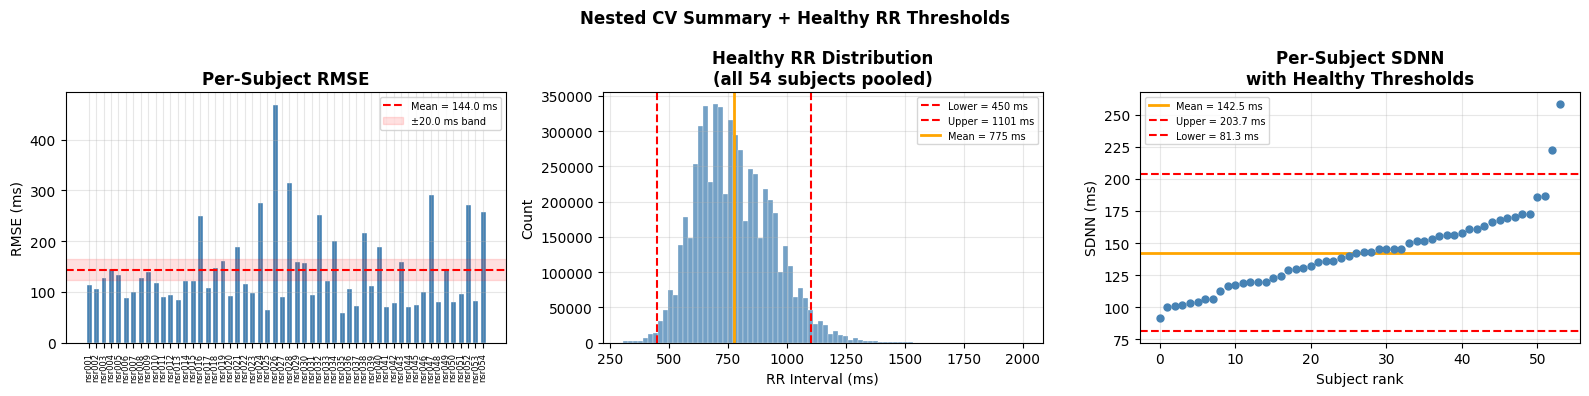

In [ ]:
# ============================================================
# CELL D — Summary + variability check + healthy RR thresholds
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

CHECKPOINT_PATH          = "/content/drive/MyDrive/ALS Heart Rate Data/lstm_loocv_results_v3.csv"
VARIABILITY_THRESHOLD_MS = 20.0   # std(RMSE) above this = high-variance model

results_df = pd.read_csv(CHECKPOINT_PATH)
mean_rmse  = results_df["rmse_ms"].mean()
std_rmse   = results_df["rmse_ms"].std()

# ── Part 1: LOOCV summary ─────────────────────────────────────────────────────
print("=" * 55)
print(f"Nested LOOCV Results  ({len(results_df)} subjects)")
print("=" * 55)
print(f"Mean RMSE : {mean_rmse:.2f} ms")
print(f"Std  RMSE : {std_rmse:.2f} ms")
print()

metrics = ["mean_rr", "sdnn", "rmssd", "sd1", "sd2"]
print(f"{'Metric':<12} {'Real':>12} {'Synthetic':>12} {'Abs Error':>12}")
print("-" * 50)
for m in metrics:
    r = results_df[f"real_{m}"].mean()
    s = results_df[f"syn_{m}"].mean()
    print(f"{m:<12} {r:>12.2f} {s:>12.2f} {abs(r-s):>12.2f}")

print("\nMost frequent winning hyperparameter combos:")
print(results_df[["best_lstm1","best_lstm2","best_dropout"]].value_counts().head(5).to_string())

# ── Part 2: Variability check ─────────────────────────────────────────────────
print("\n" + "=" * 55)
print(f"Variability Check  (threshold = {VARIABILITY_THRESHOLD_MS} ms)")
print("=" * 55)
if std_rmse > VARIABILITY_THRESHOLD_MS:
    print(f"WARNING: std(RMSE) = {std_rmse:.2f} ms exceeds threshold.")
    print("  Model is subject-sensitive. Consider more regularization.")
else:
    print(f"OK: std(RMSE) = {std_rmse:.2f} ms is within threshold.")
    print("  Model is stable across subjects.")

# ── Part 3: Healthy RR thresholds ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("Healthy RR Thresholds  (54 NSR subjects)")
print("=" * 55)

all_beats   = np.concatenate(list(rr_signals.values()))
pop_mean    = float(np.mean(all_beats))
pop_std     = float(np.std(all_beats, ddof=1))
rr_lo, rr_hi = pop_mean - 2*pop_std, pop_mean + 2*pop_std

per_sdnn  = [float(np.std(s, ddof=1))               for s in rr_signals.values()]
per_rmssd = [float(np.sqrt(np.mean(np.diff(s)**2))) for s in rr_signals.values()]

sdnn_mean,  sdnn_std  = np.mean(per_sdnn),  np.std(per_sdnn,  ddof=1)
rmssd_mean, rmssd_std = np.mean(per_rmssd), np.std(per_rmssd, ddof=1)

print(f"\nBeat-level RR  — normal range: {rr_lo:.1f} – {rr_hi:.1f} ms")
print(f"Subject SDNN   — normal range: {max(0, sdnn_mean-2*sdnn_std):.1f} – {sdnn_mean+2*sdnn_std:.1f} ms")
print(f"Subject RMSSD  — normal range: {max(0, rmssd_mean-2*rmssd_std):.1f} – {rmssd_mean+2*rmssd_std:.1f} ms")

HEALTHY_THRESHOLDS = {
    "rr_lower":    rr_lo,
    "rr_upper":    rr_hi,
    "sdnn_lower":  max(0, sdnn_mean  - 2*sdnn_std),
    "sdnn_upper":  sdnn_mean  + 2*sdnn_std,
    "rmssd_lower": max(0, rmssd_mean - 2*rmssd_std),
    "rmssd_upper": rmssd_mean + 2*rmssd_std,
}
print("\nHEALTHY_THRESHOLDS dict ready for ALS comparison cells.")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.bar(range(len(results_df)), results_df["rmse_ms"].values, color="steelblue", edgecolor="white")
ax.axhline(mean_rmse, color="red", linestyle="--", label=f"Mean = {mean_rmse:.1f} ms")
ax.axhspan(mean_rmse - VARIABILITY_THRESHOLD_MS, mean_rmse + VARIABILITY_THRESHOLD_MS,
           alpha=0.12, color="red", label=f"±{VARIABILITY_THRESHOLD_MS} ms band")
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df["subject"].str.replace("_rr.txt","", regex=False), rotation=90, fontsize=6)
ax.set_ylabel("RMSE (ms)"); ax.set_title("Per-Subject RMSE", fontweight="bold")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(all_beats, bins=80, color="steelblue", alpha=0.75, edgecolor="white", linewidth=0.3)
ax.axvline(rr_lo,    color="red",    linestyle="--", linewidth=1.5, label=f"Lower = {rr_lo:.0f} ms")
ax.axvline(rr_hi,    color="red",    linestyle="--", linewidth=1.5, label=f"Upper = {rr_hi:.0f} ms")
ax.axvline(pop_mean, color="orange", linestyle="-",  linewidth=2,   label=f"Mean = {pop_mean:.0f} ms")
ax.set_xlabel("RR Interval (ms)"); ax.set_ylabel("Count")
ax.set_title("Healthy RR Distribution\n(all 54 subjects pooled)", fontweight="bold")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.scatter(range(len(per_sdnn)), sorted(per_sdnn), color="steelblue", s=25, zorder=3)
ax.axhline(sdnn_mean,              color="orange", linestyle="-",  linewidth=2,   label=f"Mean = {sdnn_mean:.1f} ms")
ax.axhline(sdnn_mean + 2*sdnn_std, color="red",    linestyle="--", linewidth=1.5, label=f"Upper = {sdnn_mean+2*sdnn_std:.1f} ms")
ax.axhline(max(0, sdnn_mean - 2*sdnn_std), color="red", linestyle="--", linewidth=1.5,
           label=f"Lower = {max(0, sdnn_mean-2*sdnn_std):.1f} ms")
ax.set_xlabel("Subject rank"); ax.set_ylabel("SDNN (ms)")
ax.set_title("Per-Subject SDNN\nwith Healthy Thresholds", fontweight="bold")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle("Nested CV Summary + Healthy RR Thresholds", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ALS Heart Rate Data/results_summary.png", dpi=120, bbox_inches="tight")
plt.show()

# variability observing in model is greater than threshold
# find thereshold for healthy indviduals to beocming abnormal rr interval
